## 📘 Monthly Exposure to Health Hazards

This notebook explores **which admin 1 regions have the highest number of vulnerable people (aged below 1 or over 65) exposed on average per month to any health hazard**, relative to their total population. The analysis is spatially explicit and focuses on extreme weather hazards relevant to health outcomes.

---

### 🔍 Objectives
- Identify admin 1 regions with high monthly exposure of vulnerable populations.
- Explore when hazards tend to co-occur (seasonality)
- Compare hazard exposure between two periods (e.g. 2003–2012 vs. 2013–2021).
- Visualise changes in exposure patterns across administrative regions.

---

### 📂 Inputs
- Preprocessed exposure and impact data (`imp_combined`)
.

---

### 🗺️ Outputs
- Grid of global maps showing **change in monthly exposure** to:
  - One or more hazards
  - Two or more hazards
  - Three or more hazards
- Hotspot admin 1 regions are visually highlighted.
- Plots showing the seasonality of the exposure to hazards.
- Output figure saved as `.pdf`

---

### 🧩 Requirements
- Python libraries: `geopandas`, `matplotlib`, `numpy`, `cartopy`
- Custom modules:
  - `config.py` (for paths and directories)
  - Data structures defined in `imp_combined['all']`

---

### 📝 Notes
- Robinson projection is used for consistent global visualisation.
- Very low-impact events (`< 1e6 people exposed`) are filtered out.
- Latitude and longitude values are derived from geometry if missing.


In [1]:
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '../exposure_to_hazards/')

from config import FIGURES, HAZARDS, DATA_DIR

In [2]:
import geopandas as gpd
import pandas as pd
from cartopy import crs
import matplotlib.pyplot as plt
import matplotlib as mpl

In [3]:
from pathlib import Path
import itertools
from climada.engine import Impact

combinations = []

hazards = ['RF', 'EP', 'DR', 'HW', 'FI', 'TC']  # Keep 'FI' for file names

for r in range(1, len(hazards) + 1):
    combinations.extend(list(itertools.combinations(hazards, r)))

combinations = ["-".join(combi) for combi in combinations]

IMPACT_DIR = DATA_DIR / "impacts"

imp_combined = {}
for age in ['all', '0_1', '65_70_75_80']:
    imp_combined[age] = {}
    for combi in combinations:
        # Create the dictionary key with 'FI' replaced by 'WF'
        dict_key = combi.replace('FI', 'WF')
        
        imp_combined[age][dict_key] = Impact.from_csv(IMPACT_DIR / f"csv/{combi}_{age}_2003_2022.csv")
        imp_combined[age][dict_key].imp_mat = Impact.read_sparse_csr(IMPACT_DIR / f"npz/{combi}_{age}_2003_2022.npz")
        imp_combined[age][dict_key]


2025-06-24 08:18:33,076 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


/Users/szelie/python_projects/climada_python/climada/engine/impact.py:1516: DtypeWarning: Columns (1,5,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  imp_df = pd.read_csv(file_name)


2025-06-24 08:18:33,604 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


/Users/szelie/python_projects/climada_python/climada/engine/impact.py:1516: DtypeWarning: Columns (1,5,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  imp_df = pd.read_csv(file_name)


2025-06-24 08:18:34,103 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


...

/Users/szelie/python_projects/climada_python/climada/engine/impact.py:1516: DtypeWarning: Columns (1,5,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  imp_df = pd.read_csv(file_name)


2025-06-24 08:19:55,210 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


/Users/szelie/python_projects/climada_python/climada/engine/impact.py:1516: DtypeWarning: Columns (1,5,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  imp_df = pd.read_csv(file_name)


2025-06-24 08:19:55,631 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


/Users/szelie/python_projects/climada_python/climada/engine/impact.py:1516: DtypeWarning: Columns (1,5,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  imp_df = pd.read_csv(file_name)


/var/folders/f5/lms0b90j1kx7kk4v552qkjqw0000gp/T/ipykernel_10263/3650252594.py:17: DtypeWarning: Columns (5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  agg_regions = pd.read_csv(DATA_DIR / "population/all_worldpop_admin_by_point.csv")
/var/folders/f5/lms0b90j1kx7kk4v552qkjqw0000gp/T/ipykernel_10263/3650252594.py:59: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


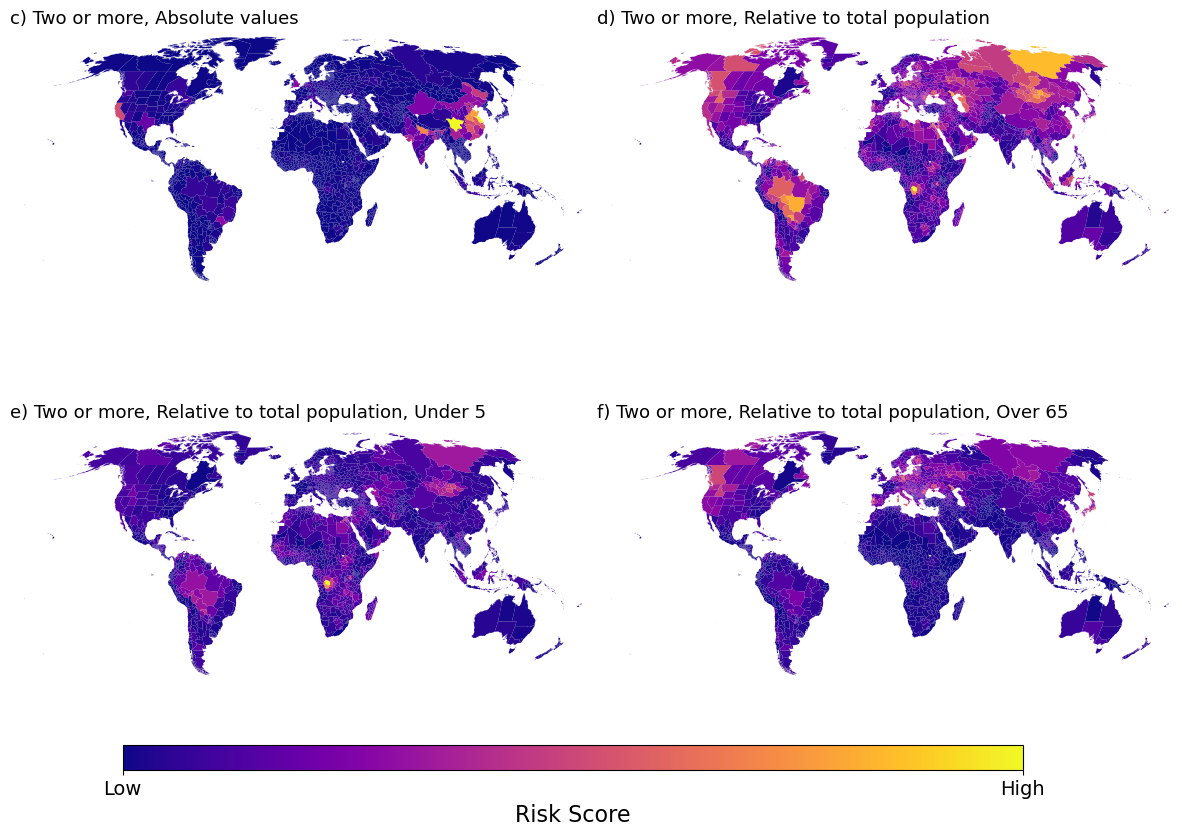

In [4]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib as mpl
from cartopy import crs
from plot_functions import *

# Function to normalize a column in a DataFrame after aggregation
def normalize_data(data, column):
    min_val = data[column].min()
    max_val = data[column].max()
    data[f'Normalized {column}'] = (data[column] - min_val) / (max_val - min_val)
    return data

# Load datasets
agg_regions = pd.read_csv(DATA_DIR / "population/all_worldpop_admin_by_point.csv")
agg_regions['numeric'] = pd.factorize(agg_regions["ADM1_ID"])[0]
adm1_pop_by_year = pd.read_csv(DATA_DIR / "population/all_worldpop_by_admin1_by_year_2000_2022.csv")
gdf_adm1 = gpd.read_file(DATA_DIR / "population/geoBoundariesCGAZ_ADM1_renamed/geoBoundariesCGAZ_ADM1.shp")

# Compute area in km² correctly
equal_area_crs = "EPSG:6933"  # World Mollweide projection
gdf_adm1_projected = gdf_adm1.to_crs(equal_area_crs)
min_area_km2 = 500
gdf_adm1["area_km2"] = gdf_adm1_projected.geometry.area / 10**6
filtered_gdf_adm1 = gdf_adm1[gdf_adm1["area_km2"] > min_area_km2]

# Titles for subfigures
titles = [
    "Two or more, Absolute values",
    "Two or more, Relative to total population",
    "Two or more, Relative to total population, Under 5",
    "Two or more, Relative to total population, Over 65"
]

# Define risk score parameters (For "Two or more" instead of "Three or more")
risk_parameters = {
    "Two or more: all (absolute)": {'age': 'all', 'hazards': 2, 'risk_score_type': 'impact'},
    "Two or more: all (relative)": {'age': 'all', 'hazards': 2, 'risk_score_type': 'relative_impact'},
    "Under 5 (relative)": {'age': '0_1', 'hazards': 2, 'risk_score_type': 'relative_impact'},
    "Over 65 (relative)": {'age': '65_70_75_80', 'hazards': 2, 'risk_score_type': 'relative_impact'},
}

# Generate risk scores
risk_score_data = {description: calculate_risk_score(imp_combined, agg_regions, gdf_adm1, adm1_pop_by_year, **params) 
                    for description, params in risk_parameters.items()}

# Initialize figure for the 2x2 bottom plots
fig, axs = plt.subplots(2, 2, figsize=(15, 10), subplot_kw={'projection': crs.Robinson()})
plt.subplots_adjust(hspace=0.02, wspace=0.02, bottom=0.15)

# Define colormap and borders
cmap = 'plasma'
plot_index = 0
alphabet = ['c', 'd', 'e', 'f']  # Continuing from previous plots

# Load country borders for better visibility
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Container to store top 5 hotspots for each risk parameter
top_5_hotspots = {}

# Plot each risk score
for description, gdf in risk_score_data.items():
    # Calculate mean impact per region
    mean_imp_at_reg = gdf.groupby(["ADM1_ID", "ADM1_NAME", "ISO3"]).mean().reset_index()
    
    # Merge with spatial data
    gdf_merged = filtered_gdf_adm1.merge(mean_imp_at_reg, on=["ADM1_ID", "ADM1_NAME", "ISO3"], how='left')
    gdf_merged["geometry"] = gdf_merged["geometry"].clip((-180, -59.48, 179.9999999, 83.64))
    gdf_merged = gdf_merged.to_crs(crs.Robinson())

    # Normalize data for better visualization
    column = 'Risk Score'
    gdf_merged = normalize_data(gdf_merged, column)
    column = f'Normalized {column}'
    norm = mpl.colors.Normalize(vmin=gdf_merged[column].min(), vmax=gdf_merged[column].max())

    ax = axs[plot_index // 2, plot_index % 2]
    
    # Plot the data
    gdf_merged.plot(column=column, cmap=cmap, ax=ax, norm=norm)
    gdf_adm1[gdf_adm1["area_km2"] < min_area_km2].plot(ax=ax, facecolor="lightgrey")

    # Improve title readability
    title_desc = f"{alphabet[plot_index]}) {titles[plot_index]}"
    ax.set_title(title_desc, loc='left', fontsize=13)
    ax.axis('off')

    # Identify and store top 5 hotspots for each risk score
    top_5 = gdf_merged.nlargest(5, column)[['ADM1_NAME', 'ISO3', column]]
    top_5_hotspots[description] = top_5

    plot_index += 1

# Adjust figure layout
fig.subplots_adjust(bottom=0.1)

# Add colorbar
cbar_ax = fig.add_axes([0.2, 0.08, 0.6, 0.025])
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), cax=cbar_ax, orientation='horizontal')
cbar.set_label('Population at risk (millions)' if 'absolute' in description else 'Risk Score', fontsize=16)
cbar.ax.tick_params(labelsize=14)  # Adjust the font size (e.g., 16 or larger)
cbar.set_ticks([norm.vmin, norm.vmax])  # Only show min and max values
cbar.set_ticklabels(["Low", "High"])  # Replace numbers with text labels

# Save and show plot
plt.savefig(Path('/Users/szelie/Dropbox/Applications/Overleaf/health_multi_hazard_SI_revisions') / "hotspot_two_or_more.pdf", dpi=400, bbox_inches='tight')
plt.show()

# # Print top 5 hotspots for each category
# for desc, top5 in top_5_hotspots.items():
#     print(f"Top 5 Hotspots for {desc}:\n", top5.to_string(index=False), "\n")

# # Save the top 5 hotspots table to a CSV file
# df_top5 = pd.concat(top_5_hotspots).reset_index().rename(columns={"level_0": "Risk Type"})


/var/folders/f5/lms0b90j1kx7kk4v552qkjqw0000gp/T/ipykernel_10263/1505258398.py:17: DtypeWarning: Columns (5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  agg_regions = pd.read_csv(DATA_DIR / "population/all_worldpop_admin_by_point.csv")
/var/folders/f5/lms0b90j1kx7kk4v552qkjqw0000gp/T/ipykernel_10263/1505258398.py:64: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


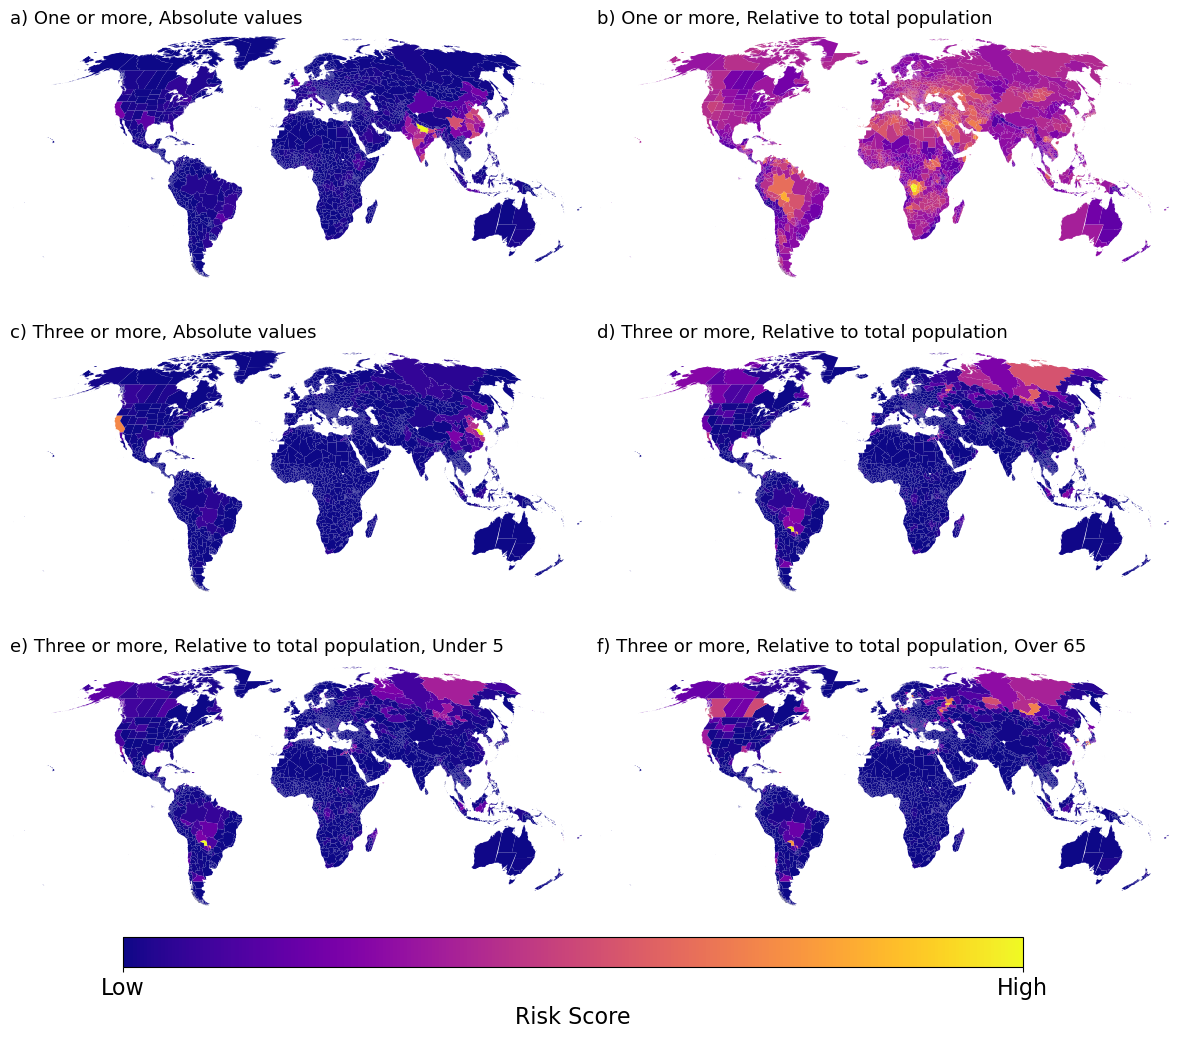

Top 5 Hotspots for One or more: all (absolute):
          ADM1_NAME ISO3  Normalized Risk Score
     Uttar Pradesh  IND               1.000000
    Henan Province  CHN               0.539093
  Sichuan Province  CHN               0.537437
  Jiangsu Province  CHN               0.527097
       Mah?r?shtra  IND               0.506060
Guangzhou Province  CHN               0.499815
       West Bengal  IND               0.497733
             Bih?r  IND               0.493042
        Tamil N?du  IND               0.488141
 Shandong Province  CHN               0.480246 

Top 5 Hotspots for One or more: all (relative):
      ADM1_NAME ISO3  Normalized Risk Score
        Kwango  COD               1.000000
         Kwilu  COD               0.977490
   Lunda Norte  AGO               0.833025
      Rondonia  BRA               0.819605
         Kasai  COD               0.817997
        Muscat  OMN               0.758780
 Ad Dakhiliyah  OMN               0.745852
Al Jawf Region  SAU               0.735

In [7]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib as mpl
from cartopy import crs
from plot_functions import *

# Function to normalize a column in a DataFrame after aggregation
def normalize_data(data, column):
    min_val = data[column].min()
    max_val = data[column].max()
    data[f'Normalized {column}'] = (data[column] - min_val) / (max_val - min_val)
    return data

# Load datasets
agg_regions = pd.read_csv(DATA_DIR / "population/all_worldpop_admin_by_point.csv")
agg_regions['numeric'] = pd.factorize(agg_regions["ADM1_ID"])[0]
adm1_pop_by_year = pd.read_csv(DATA_DIR / "population/all_worldpop_by_admin1_by_year_2000_2022.csv")
gdf_adm1 = gpd.read_file(DATA_DIR / "population/geoBoundariesCGAZ_ADM1_renamed/geoBoundariesCGAZ_ADM1.shp")

equal_area_crs = "EPSG:6933"  # World Mollweide projection
gdf_adm1_projected = gdf_adm1.to_crs(equal_area_crs)
# Compute area in km² correctly
min_area_km2=500
gdf_adm1["area_km2"] = gdf_adm1_projected.geometry.area / 10**6
filtered_gdf_adm1 = gdf_adm1[gdf_adm1["area_km2"] > min_area_km2]

# Titles for subfigures
titles = [
    "One or more, Absolute values",
    "One or more, Relative to total population",
    "Three or more, Absolute values",
    "Three or more, Relative to total population",
    "Three or more, Relative to total population, Under 5",
    "Three or more, Relative to total population, Over 65"
]

# Define risk score parameters
risk_parameters = {
    "One or more: all (absolute)": {'age': 'all', 'hazards': 1, 'risk_score_type': 'impact'},
    "One or more: all (relative)": {'age': 'all', 'hazards': 1, 'risk_score_type': 'relative_impact'},
    "Three or more: all (absolute)": {'age': 'all', 'hazards': 3, 'risk_score_type': 'impact'},
    "Three or more: all (relative)": {'age': 'all', 'hazards': 3, 'risk_score_type': 'relative_impact'},
    "Under 5 (relative)": {'age': '0_1', 'hazards': 3, 'risk_score_type': 'relative_impact'},
    "Over 65 (relative)": {'age': '65_70_75_80', 'hazards': 3, 'risk_score_type': 'relative_impact'}
}

# Generate risk scores
risk_score_data = {description: calculate_risk_score(imp_combined, agg_regions, gdf_adm1, adm1_pop_by_year, **params) 
                    for description, params in risk_parameters.items()}

# Initialize figure
fig, axs = plt.subplots(3, 2, figsize=(15, 12), subplot_kw={'projection': crs.Robinson()})
plt.subplots_adjust(hspace=0.02, wspace=0.02, bottom=0.15)

# Define colormap and borders
cmap = 'plasma'
max_values = []
plot_index = 0
alphabet = ['a', 'b', 'c', 'd', 'e', 'f']

# Load country borders for better visibility
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Container to store top 5 hotspots for each risk parameter
top_5_hotspots = {}
filtered_gdf_adm1["geometry"] = filtered_gdf_adm1["geometry"].simplify(0.05, preserve_topology=True)

# Plot each risk score
for description, gdf in risk_score_data.items():

    # Calculate mean impact per region
    mean_imp_at_reg = gdf.groupby(["ADM1_ID", "ADM1_NAME", "ISO3"]).mean().reset_index()
    
    # Merge with spatial data
    robinson = crs.Robinson().proj4_init
    gdf_merged = filtered_gdf_adm1.merge(mean_imp_at_reg, on=["ADM1_ID", "ADM1_NAME", "ISO3"], how='left')
    gdf_merged["geometry"] = gdf_merged["geometry"].clip((-180, -59.48, 179.9999999, 83.64))
    gdf_merged = gdf_merged.to_crs(robinson)

    # Normalize data for better visualization
    column = 'Risk Score'
    gdf_merged = normalize_data(gdf_merged, column)
    column = f'Normalized {column}'
    norm = mpl.colors.Normalize(vmin=gdf_merged[column].min(), vmax=gdf_merged[column].max())

    ax = axs[plot_index // 2, plot_index % 2]
    
    # Plot the data
    gdf_merged.plot(column=column, cmap=cmap, ax=ax, norm=norm)

    # Add thin country borders for readability
    #world.to_crs(robinson).boundary.plot(ax=ax, linewidth=0.4, color='white')

    # Improve title readability
    title_desc = f"{alphabet[plot_index]}) {titles[plot_index]}"
    ax.set_title(title_desc, loc='left', fontsize=13)
    ax.axis('off')
     # Identify the max ADM1_NAME and the top 5 hotspots
    max_adm1 = gdf_merged.loc[gdf_merged[column].idxmax(), 'ADM1_NAME']
    max_adm0 = gdf_merged.loc[gdf_merged[column].idxmax(), 'ISO3']

    max_values.append({
        'ADM1_NAME': max_adm1,
        'ISO3': max_adm0,
    })
    # Set tick marks and gridlines
    ax.set_xticks([-180, -90, 0, 90, 180])
    ax.set_yticks([-60, -30, 0, 30, 60])
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    
   # Extract the top 5 hotspots for the current risk score
    top_5 = gdf_merged.nlargest(10, column)[['ADM1_NAME', 'ISO3', column]]
    top_5_hotspots[description] = top_5

    plot_index += 1


# Adjust figure layout
fig.subplots_adjust(bottom=0.1)

# Add improved colorbar
cbar_ax = fig.add_axes([0.2, 0.08, 0.6, 0.025])  # Reduce bottom (from 0.05 to 0.08)
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), cax=cbar_ax, orientation='horizontal')
cbar.set_label('Population at risk (millions)' if 'absolute' in description else 'Risk Score', fontsize=16)
cbar.ax.tick_params(labelsize=16)  # Adjust the font size (e.g., 16 or larger)
cbar.set_ticks([norm.vmin, norm.vmax])  # Only show min and max values
cbar.set_ticklabels(["Low", "High"])  # Replace numbers with text labels

# Save the max values
df_max_values = pd.DataFrame(max_values)
df_max_values.to_csv("max_values_table.csv", index=False)

# Save and show plot
plt.savefig(FIGURES / "hotspot.pdf", dpi=300, bbox_inches='tight')
plt.show()
# Print top 5 hotspots
for desc, top5 in top_5_hotspots.items():
    print(f"Top 5 Hotspots for {desc}:\n", top5.to_string(index=False), "\n")


In [7]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib as mpl
from cartopy import crs
from plot_functions import *

# Function to normalize a column in a DataFrame after aggregation
def normalize_data(data, column):
    min_val = data[column].min()
    max_val = data[column].max()
    data[f'Normalized {column}'] = (data[column] - min_val) / (max_val - min_val)
    return data

# Load datasets
agg_regions = pd.read_csv(DATA_DIR / "population/all_worldpop_admin_by_point.csv")
agg_regions['numeric'] = pd.factorize(agg_regions["ADM1_ID"])[0]
adm1_pop_by_year = pd.read_csv(DATA_DIR / "population/all_worldpop_by_admin1_by_year_2000_2022.csv")
gdf_adm1 = gpd.read_file(DATA_DIR / "population/geoBoundariesCGAZ_ADM1_renamed/geoBoundariesCGAZ_ADM1.shp")

# Filter small areas using projected area
equal_area_crs = "EPSG:6933"  # World Mollweide
gdf_adm1_projected = gdf_adm1.to_crs(equal_area_crs)
min_area_km2 = 500
gdf_adm1["area_km2"] = gdf_adm1_projected.geometry.area / 10**6
filtered_gdf_adm1 = gdf_adm1[gdf_adm1["area_km2"] > min_area_km2]

# Define risk score parameters
risk_parameters = {
    "One or more: all (absolute)": {'age': 'all', 'hazards': 1, 'risk_score_type': 'impact'},
    "One or more: all (relative)": {'age': 'all', 'hazards': 1, 'risk_score_type': 'relative_impact'},
    "Three or more: all (absolute)": {'age': 'all', 'hazards': 3, 'risk_score_type': 'impact'},
    "Three or more: all (relative)": {'age': 'all', 'hazards': 3, 'risk_score_type': 'relative_impact'},
    "Under 5 (relative)": {'age': '0_1', 'hazards': 3, 'risk_score_type': 'relative_impact'},
    "Over 65 (relative)": {'age': '65_70_75_80', 'hazards': 3, 'risk_score_type': 'relative_impact'}
}

# Compute risk scores
risk_score_data = {
    description: calculate_risk_score(imp_combined, agg_regions, gdf_adm1, adm1_pop_by_year, **params)
    for description, params in risk_parameters.items()
}

# Prepare to store GeoDataFrames
gdf_output_dict = {}

# Loop through each and normalize
for description, df in risk_score_data.items():
    # Aggregate to mean per ADM1
    mean_imp = df.groupby(["ADM1_ID", "ADM1_NAME", "ISO3"]).mean().reset_index()
    
    # Merge with filtered geometries
    gdf_merged = filtered_gdf_adm1.merge(mean_imp, on=["ADM1_ID", "ADM1_NAME", "ISO3"], how='left')
    
    # Normalize Risk Score
    column = "Risk Score"
    gdf_merged = normalize_data(gdf_merged, column)
    
    # Store result (in original CRS EPSG:4326)
    gdf_output_dict[description] = gdf_merged.to_crs("EPSG:4326")

# === Merge all into a single GeoDataFrame ===

# Start from the first GeoDataFrame
first_key = next(iter(gdf_output_dict))
combined_gdf = gdf_output_dict[first_key][['ADM1_ID', 'ADM1_NAME', 'geometry']].copy()

# Loop through and add each normalized column
for desc, gdf in gdf_output_dict.items():
    colname = desc.lower().replace(" ", "_").replace(":", "").replace(",", "")
    norm_col = [c for c in gdf.columns if "normalized" in c.lower()][0]  # detect normalized column
    gdf_subset = gdf[['ADM1_ID', norm_col]].rename(columns={norm_col: colname})
    combined_gdf = combined_gdf.merge(gdf_subset, on='ADM1_ID', how='left')

# Drop rows with all NaNs in score columns
data_cols = combined_gdf.columns.difference(['ADM1_ID', 'geometry', 'ADM1_NAME'])
combined_gdf = combined_gdf.dropna(subset=data_cols, how='all')

# Save if needed
# combined_gdf.to_file(DATA_DIR / "population" / "combined_risk_scores.gpkg", layer="risk_scores", driver="GPKG")

# Done — you now have `combined_gdf` with one column per risk score


/var/folders/f5/lms0b90j1kx7kk4v552qkjqw0000gp/T/ipykernel_40335/1821234413.py:17: DtypeWarning: Columns (5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  agg_regions = pd.read_csv(DATA_DIR / "population/all_worldpop_admin_by_point.csv")


In [8]:
# Clean parentheses from column names
combined_gdf.columns = combined_gdf.columns.str.replace(r"[()]", "", regex=True)

# Rename specific columns for clarity
combined_gdf = combined_gdf.rename(columns={
    "under_5_relative": "under_5_three_or_more_relative",
    "over_65_relative": "over_65_three_or_more_relative"
})

In [11]:
combined_gdf.to_csv(DATA_DIR/"risk_scores.csv")

In [ ]:
DATA_DIR

In [12]:
df_max_values.at[4, 'ADM1_NAME'] = 'Darkhan-Uul'
df_max_values.at[4, 'ISO3'] = 'MNG'



In [13]:
import scipy.sparse as sp
import climada.util.coordinates as u_coord
import copy
import datetime
import xarray as xr
import copy
import datetime
import pandas as pd
import numpy as np
pair_tuple_keys = [key for key in imp_combined.keys() if len(key) == 5]
single_tuple_keys = [key for key in imp_combined.keys() if len(key) == 3]

In [14]:
age = "all" # for the rest of the plots we work with all ages
imp_combined_at_reg = {}
for combi in imp_combined[age]:
    imp_combined_at_reg[combi]=imp_combined[age][combi].impact_at_reg(agg_regions=agg_regions['numeric'])

for combi in imp_combined_at_reg:
    at_reg = copy.deepcopy(imp_combined_at_reg[combi])
    at_reg['month'] = [datetime.datetime.fromordinal(int(date)).month for date in imp_combined[age][combi].date]
    at_reg['year'] = [datetime.datetime.fromordinal(int(date)).year for date in imp_combined[age][combi].date]

    melted_df1 = at_reg.melt(id_vars=['month', 'year'], var_name='numeric', value_name='impact')
    melted_df1 = melted_df1.merge(agg_regions[["numeric","ADM1_NAME", "ADM1_ID"]].drop_duplicates())


In [15]:
import matplotlib.pyplot as plt
from cartopy import crs
import geopandas as gpd

rel_country_imp = {}
mean_rel_country_imp = {}

for combi in imp_combined[age]:

    at_reg = imp_combined[age][combi].impact_at_reg(agg_regions=agg_regions['numeric'])
    
    # Prepare the data for plotting
    at_reg['month'] = [datetime.datetime.fromordinal(int(date)).month for date in imp_combined[age][combi].date]
    at_reg['year'] = [datetime.datetime.fromordinal(int(date)).year for date in imp_combined[age][combi].date]
    
    # Melt and merge data
    at_reg_melted = at_reg.melt(id_vars=['month', 'year'], var_name='numeric', value_name='impact')
    at_reg_melted = at_reg_melted.merge(agg_regions[["ADM1_ID", "ADM1_NAME", "ISO3", "numeric"]].drop_duplicates())
    at_reg_melted = at_reg_melted.merge(adm1_pop_by_year, on=['year', "ADM1_ID", "ADM1_NAME", "ISO3"], how='inner')

    
    at_reg_melted['relative_impact'] = at_reg_melted['impact'] / at_reg_melted['value']

    rel_country_imp[combi] = at_reg_melted
    

/var/folders/f5/lms0b90j1kx7kk4v552qkjqw0000gp/T/ipykernel_40335/3885092649.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


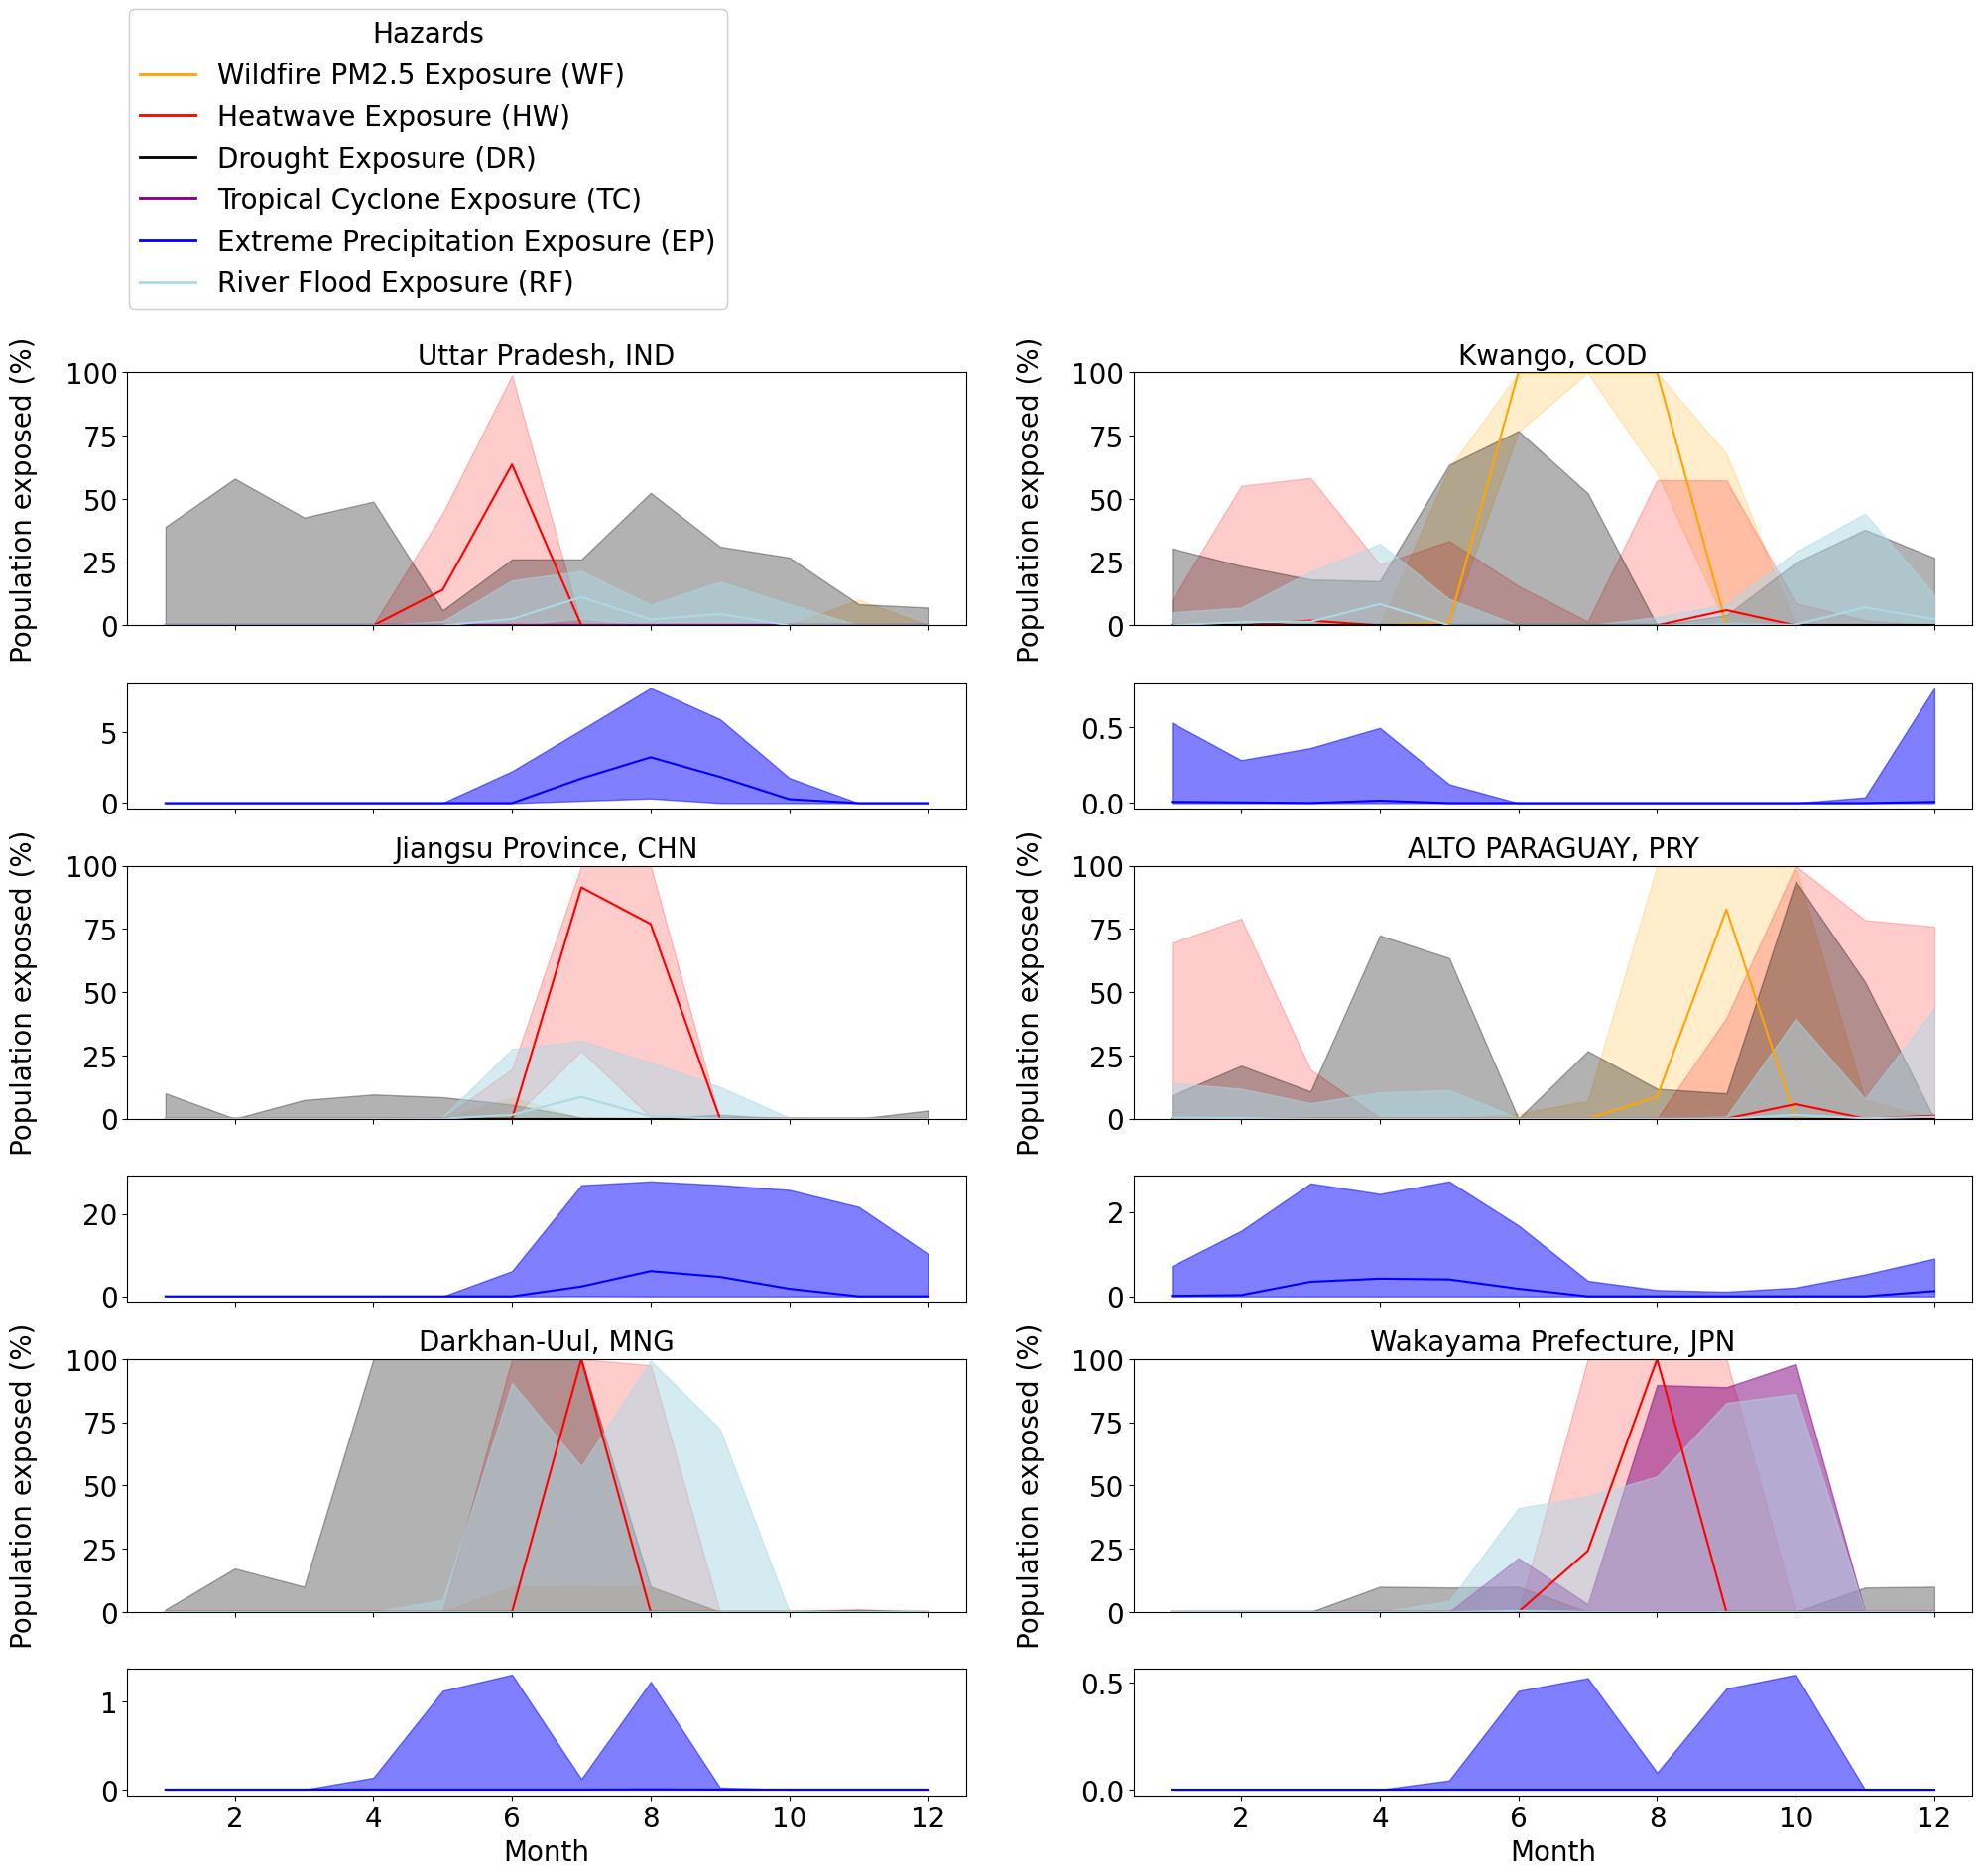

In [16]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.lines import Line2D
from plot_functions import *

# Define colors and transparency for different event types
colors_dict = {
    "WF": "orange", 
    "HW": "red", 
    "DR": "black", 
    "TC": "purple", 
    "RF": "blue", 
    "EP": "lightblue",
}

alpha_dict = {
    "WF": 0.2, 
    "HW": 0.2, 
    "DR": 0.3, 
    "TC": 0.5, 
    "RF": 0.5, 
    "EP": 0.5,
}

# Labels for the legend
legend_labels_median = [
    "Wildfire PM2.5 Exposure (WF)", 
    "Heatwave Exposure (HW)", 
    "Drought Exposure (DR)", 
    "Tropical Cyclone Exposure (TC)", 
    "Extreme Precipitation Exposure (EP)", 
    "River Flood Exposure (RF)"
]

legend_labels_variability = [
    "WF Variability", 
    "HW Variability", 
    "DR Variability", 
    "TC Variability", 
    "EP Variability", 
    "RF Variability"
]

# Initialize the figure with a larger size
fig = plt.figure(figsize=(24, 38))
gs = gridspec.GridSpec(nrows=12, ncols=2, height_ratios=[1, 0.5] * 6, hspace=0.3, wspace=0.2)

# Loop through each region (ADM1_NAME) to create subplots
for i, adm1_name in enumerate(df_max_values["ADM1_NAME"]):
    # Determine position in the grid
    col = i % 2
    row_main = (i // 2) * 2
    row_rf = row_main + 1

    # Create the main and secondary axes
    ax_main = fig.add_subplot(gs[row_main, col])
    ax_rf = fig.add_subplot(gs[row_rf, col])

    # Initialize variables to track the maximum impact
    max_relative_impact = 0

    # Plot data for all events except "RF"
    for key in colors_dict:
        if key != "RF":
            data = rel_country_imp[key][rel_country_imp[key].ADM1_NAME == adm1_name][["impact", "relative_impact", "month"]]
            if data['impact'].sum() > 100:  # Only plot if total impact is significant
                median_values = data.groupby("month").median()
                lower_bound = data.groupby("month").quantile(0.05)
                upper_bound = data.groupby("month").quantile(0.95)

                ax_main.plot(median_values.index, median_values['relative_impact']*100, color=colors_dict[key])
                ax_main.fill_between(median_values.index, lower_bound['relative_impact']*100, upper_bound['relative_impact']*100, 
                                     alpha=alpha_dict[key], color=colors_dict[key])

                # Track the maximum relative impact for scaling the axes
                max_relative_impact = max(max_relative_impact, data['relative_impact'].max())

    # Plot data for the "RF" event separately
    data_rf = rel_country_imp["RF"][rel_country_imp["RF"].ADM1_NAME == adm1_name][["impact", "relative_impact", "month"]]
    median_values_rf = data_rf.groupby("month").median()
    lower_bound_rf = data_rf.groupby("month").quantile(0.05)
    upper_bound_rf = data_rf.groupby("month").quantile(0.95)
    ax_rf.plot(median_values_rf.index, median_values_rf['relative_impact']*100, color=colors_dict["RF"], label=adm1_name)
    ax_rf.fill_between(median_values_rf.index, lower_bound_rf['relative_impact']*100, upper_bound_rf['relative_impact']*100, 
                       alpha=alpha_dict["RF"], color=colors_dict["RF"])

    # Set titles and labels
    country_code = np.array(adm1_pop_by_year['ISO3'][adm1_pop_by_year['ADM1_NAME'] == adm1_name])[0]
    ax_main.set_title(f"{adm1_name}, {country_code}", fontsize=20)
    ax_main.tick_params(axis='both', which='major', labelsize=20)
    ax_main.set_xticklabels([])

    # Set the y-axis for population exposed (%) on the main axis for both columns
    ax_main.set_ylabel('Population exposed (%)', fontsize=20, labelpad=20)
    ax_main.set_ylim(0, 100)
    ax_main.tick_params(axis='both', which='major', labelsize=20)

    ax_rf.tick_params(axis='both', which='major', labelsize=20)

    # Only set the xlabel for the last row
    if i // 2 == (len(df_max_values.ADM1_NAME) - 1) // 2:
        ax_rf.set_xlabel('Month', fontsize=20)
    else:
        ax_rf.set_xticklabels([])

# Create custom legend handles for the median and variability
custom_lines_median = [Line2D([0], [0], color=colors_dict[key], lw=2) for key in colors_dict]
custom_lines_variability = [Line2D([0], [0], color=colors_dict[key], lw=4, alpha=0.2) for key in colors_dict]

# Place legends at the top of the figure
leg1 = fig.legend(custom_lines_median, legend_labels_median, loc='upper left', fontsize=20, title='Hazards', bbox_to_anchor=(0.12, 0.98), title_fontsize=20)
#leg2 = fig.legend(custom_lines_variability, legend_labels_variability, loc='upper left', fontsize=18, title='Variability', bbox_to_anchor=(0.35, 0.965), title_fontsize=18)

# Add the legends to the figure
fig.add_artist(leg1)
#fig.add_artist(leg2)
plt.tight_layout()
plt.savefig(FIGURES / f"seasonality.pdf", bbox_inches='tight', dpi=400)




In [17]:
FIGURES

PosixPath('/Users/szelie/Dropbox/Applications/Overleaf/health_multi_hazard_revisions/figures')

In [18]:
age = 'all'
imp_combined_adm1 = {}
for adm1 in df_max_values["ADM1_NAME"]:
    imp_combined_adm1[adm1] = {}
    for combi in imp_combined[age]:
        adm0 = np.array(df_max_values["ISO3"][df_max_values["ADM1_NAME"]==adm1])[0]

        region_num = agg_regions[agg_regions.ISO3==adm0]["numeric"]
        print(combi)
        imp_combined_adm1[adm1][combi] = impact_select_region(imp_combined[age][combi], agg_regions.numeric, region_num)
        imp_combined_adm1[adm1][combi].unit = "people"
        imp_combined_adm1[adm1][combi].eai_exp = np.array(imp_combined_adm1[adm1][combi].imp_mat.mean(axis=0).flatten())[0]


RF
EP
DR
HW
WF
TC
RF-EP
RF-DR
RF-HW
RF-WF
RF-TC
EP-DR
EP-HW
EP-WF
EP-TC
DR-HW
DR-WF
DR-TC
HW-WF
HW-TC
WF-TC
RF-EP-DR
RF-EP-HW
RF-EP-WF
RF-EP-TC
RF-DR-HW
RF-DR-WF
RF-DR-TC
RF-HW-WF
RF-HW-TC
RF-WF-TC
EP-DR-HW
EP-DR-WF
EP-DR-TC
EP-HW-WF
EP-HW-TC
EP-WF-TC
DR-HW-WF
DR-HW-TC
DR-WF-TC
HW-WF-TC
RF-EP-DR-HW
RF-EP-DR-WF
RF-EP-DR-TC
RF-EP-HW-WF
RF-EP-HW-TC
RF-EP-WF-TC
RF-DR-HW-WF
RF-DR-HW-TC
RF-DR-WF-TC
RF-HW-WF-TC
EP-DR-HW-WF
EP-DR-HW-TC
EP-DR-WF-TC
EP-HW-WF-TC
DR-HW-WF-TC
RF-EP-DR-HW-WF
RF-EP-DR-HW-TC
RF-EP-DR-WF-TC
RF-EP-HW-WF-TC
RF-DR-HW-WF-TC
EP-DR-HW-WF-TC
RF-EP-DR-HW-WF-TC
RF
EP
DR
HW
WF
TC
RF-EP
RF-DR
RF-HW
RF-WF
RF-TC
EP-DR
EP-HW
EP-WF
EP-TC
DR-HW
DR-WF
DR-TC
HW-WF
HW-TC
WF-TC
RF-EP-DR
RF-EP-HW
RF-EP-WF
RF-EP-TC
RF-DR-HW
RF-DR-WF
RF-DR-TC
RF-HW-WF
RF-HW-TC
RF-WF-TC
EP-DR-HW
EP-DR-WF
EP-DR-TC
EP-HW-WF
EP-HW-TC
EP-WF-TC
DR-HW-WF
DR-HW-TC
DR-WF-TC
HW-WF-TC
RF-EP-DR-HW
RF-EP-DR-WF
RF-EP-DR-TC
RF-EP-HW-WF
RF-EP-HW-TC
RF-EP-WF-TC
RF-DR-HW-WF
RF-DR-HW-TC
RF-DR-WF-TC
RF-HW-WF-TC
EP-DR-HW-WF
EP-D

## to do in following plot: adapt size of points, add a km scale

In [19]:
def add_scale_bar(ax, length_km, location=(0.05, 0.05)):
    """Adds a scale bar to the given axis `ax`, with length `length_km` kilometers."""
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    
    # Calculate the central latitude for the scale conversion
    central_lat = np.mean([ymin, ymax])
    
    # Conversion from latitude to kilometers (using approximate earth radius)
    km_per_degree_lat = 110.574  # constant at any latitude for longitude it varies
    km_per_degree_lon = np.cos(np.radians(central_lat)) * 111.320  # varies by latitude
    
    # Length of scale bar in degrees of longitude
    length_deg_lon = length_km / km_per_degree_lon
    
    # Scale bar coordinates
    x_start = xmin + (xmax - xmin) * location[0]
    x_end = x_start + length_deg_lon
    y_pos = ymin + (ymax - ymin) * location[1]
    
    # Draw scale bar
    ax.plot([x_start, x_end], [y_pos, y_pos], 'k-', lw=5)
    ax.text((x_start + x_end) / 2, y_pos, f' {length_km} km', verticalalignment='bottom', 
            horizontalalignment='center', color='black', fontsize=15)

In [20]:
colors_dict_combi = {
    'RF': '#1f77b4',  # Blue
    'EP': '#1c4e80',  # Dark Blue
    'DR': '#a8a8a8',  # Grey
    'HW': 'red',  # Red
    'WF': '#ff5733',  # Orange
    'TC': '#17becf',  # Teal

    # Combinations
    'RF-EP': 'yellow',  # Mixed Blue
    'RF-DR': '#7497b4',  # Light Blue Grey
    'RF-HW': '#b46649',  # Reddish Blue
    'RF-WF': '#9c6776',  # Muted Red-Blue
    'RF-TC': '#1ca9b4',  # Light Teal

    'EP-DR': '#58749d',  # Dark Blue-Grey
    'EP-HW': '#745569',  # Dark Red-Blue
    'EP-WF': '#823344',  # Dark Reddish Blue
    'EP-TC': 'green',  # Dark Teal

    'DR-HW': 'pink',  # Warm Grey
    'DR-WF': '#c49a76',  # Greyish Orange
    'DR-TC': '#9db4c3',  # Greyish Teal

    'HW-WF': 'maroon',  # 
    'HW-TC': '#ff9266',  # Orange Teal

    'FI-TC': '#ff8466',  # Orange Teal mix

    # Triple combinations
    'RF-EP-DR': '#64768a',  # Muted Blue Grey
    'RF-EP-HW': '#8a7373',  # Muted Red Blue
    'RF-EP-WF': '#8b6473',  # Muted Orange Blue
    'RF-EP-TC': '#5293a4',  # Muted Teal Blue

    'RF-DR-HW': '#a8806b',  # Warm Greyish Blue
    'RF-DR-WF': 'darkgreen',  # Warm Greyish Red
    'RF-DR-TC': '#85a1b6',  # Light Greyish Teal
    'RF-EP-TC':'yellow',
    'RF-HW-WF': '#d4806d',  # Warm Red Orange
    'RF-HW-TC': '#c7807e',  # Warm Red Teal
    'RF-WF-TC': '#c07b71',  # Warm Orange Teal

    'EP-DR-HW': 'green',  # Grey Blue Red
    'EP-DR-WF': '#84697b',  # Grey Blue Orange
    'EP-DR-TC': '#7290a3',  # Grey Blue Teal

    'EP-HW-WF': '#99656d',  # Red Blue Orange
    'EP-HW-TC': 'purple',  # Red Blue Teal
    'EP-WF-TC': '#a36c7b',  # Orange Blue Teal

    'DR-HW-WF': 'magenta',  # Warm Grey Orange
    'DR-HW-TC': '#b29a85',  # Warm Grey Teal
    'DR-WF-TC': '#bb9a80',  # Grey Orange Teal

    'HW-WF-TC': '#ff9980',  # Bright Orange Teal

    # Quadruple combinations
    'RF-EP-DR-HW': '#9d857a',  # Muted Warm Grey
    'RF-EP-DR-WF': '#95787a',  # Muted Warm Red
    'RF-EP-DR-TC': '#7d9ba6',  # Muted Warm Teal
    'RF-EP-HW-WF': '#a4817a',  # Warm Red Orange
    'RF-EP-HW-TC': '#91807d',  # Muted Warm Teal
    'RF-EP-WF-TC': '#987b7d',  # Warm Orange Teal
    'RF-DR-HW-WF': '#b67a72',  # Greyish Warm Red
    'RF-DR-HW-TC': '#9e857e',  # Greyish Warm Teal
    'RF-DR-WF-TC': '#a37d78',  # Greyish Orange Teal
    'RF-HW-WF-TC': '#bf8a7b',  # Warm Reddish Orange Teal
    'EP-DR-HW-WF': '#a47a7d',  # Dark Warm Grey
    'EP-DR-HW-TC': '#8a818c',  # Dark Greyish Teal
    'EP-DR-WF-TC': '#987a83',  # Dark Greyish Orange Teal
    'EP-HW-WF-TC': '#9f7b81',  # Dark Reddish Orange Teal
    'DR-HW-WF-TC': '#c79b82',  # Warm Greyish Orange Teal
}

In [21]:
risk_score_data.keys()

dict_keys(['One or more: all (absolute)', 'One or more: all (relative)', 'Three or more: all (absolute)', 'Three or more: all (relative)', 'Under 5 (relative)', 'Over 65 (relative)'])

Uttar Pradesh
Kwango
Jiangsu Province
ALTO PARAGUAY
Darkhan-Uul
Wakayama Prefecture


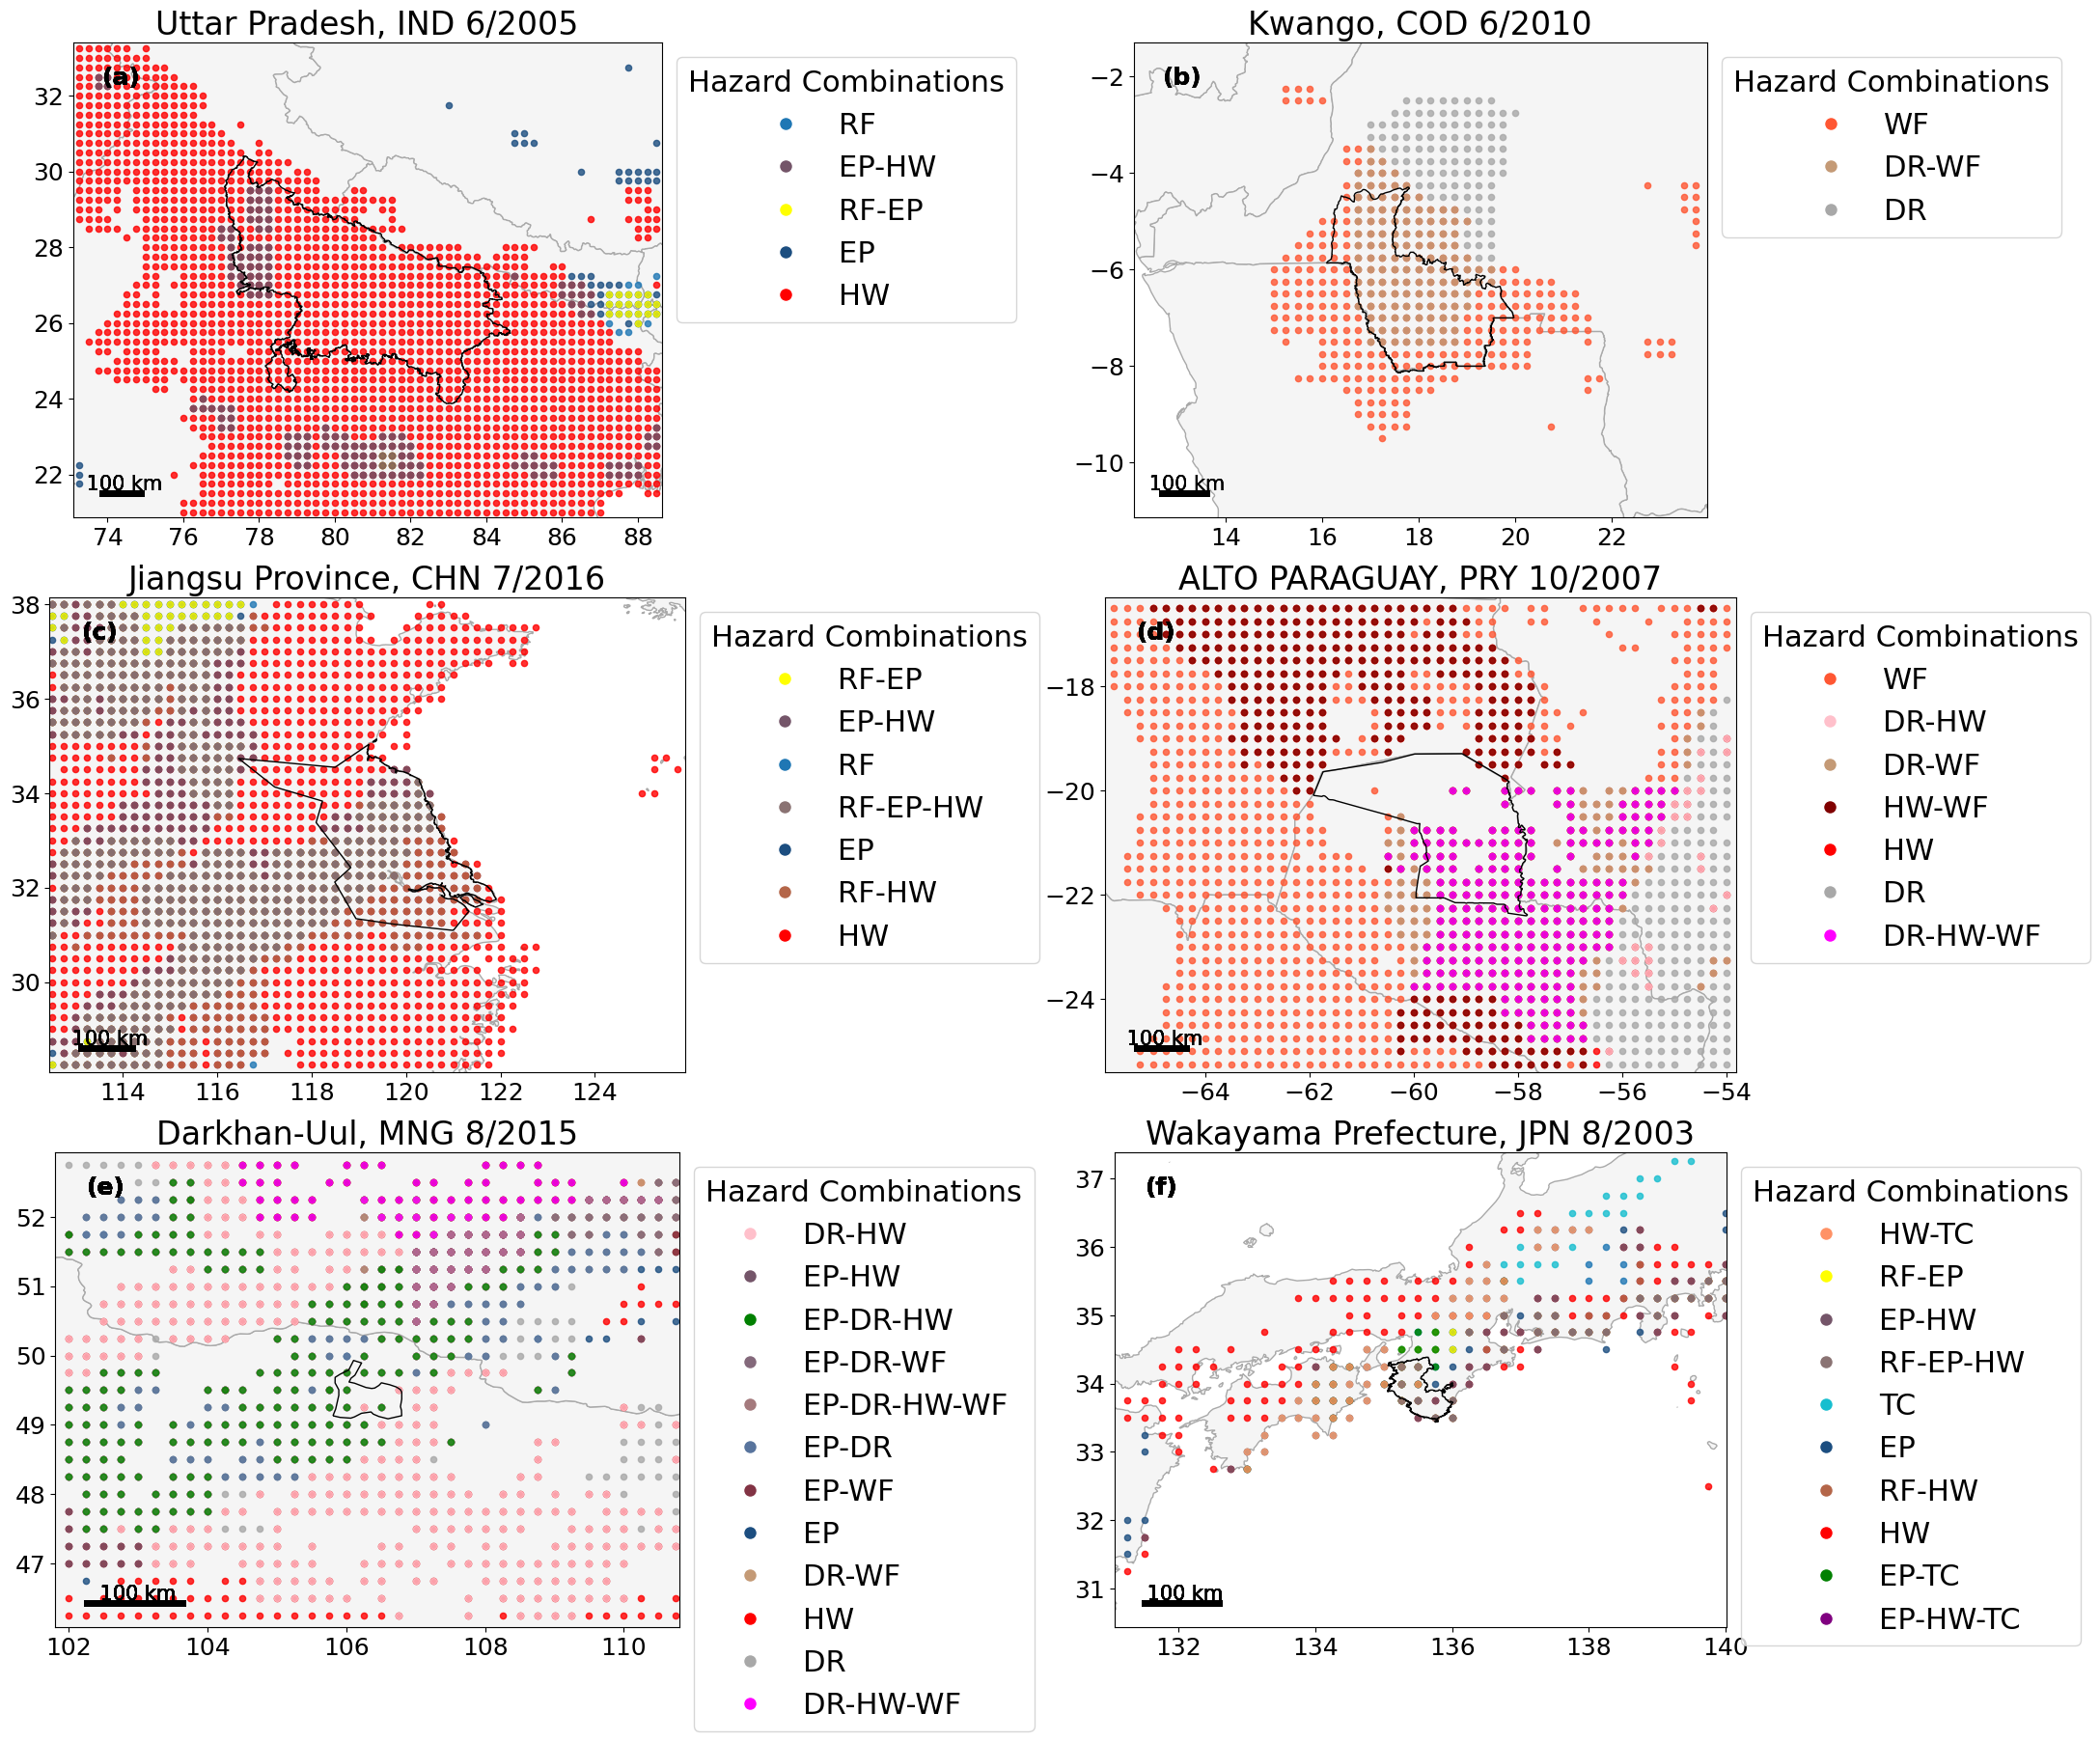

In [23]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

# Assuming 'imp_combined_countries', 'risk_score_data', 'colors', 'imp_combined', 'countries', 'FIGURES' are defined elsewhere in your code

plt.rcParams.update({'font.size': 10})  # General font size


# Load the world map
world = gpd.read_file(DATA_DIR / "population/ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp")

# Calculate the number of plots needed
num_plots = 6
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(22, 18))

# Flatten axes for easy iteration
axes = axes.flatten()

plot_index = 0
three_or_more_events = risk_score_data['Three or more: all (relative)']
one_or_more_events = risk_score_data['One or more: all (relative)']
labels = ['a', 'b', 'c', 'd', 'e', 'f']

for i, country in enumerate(df_max_values.ADM1_NAME):
    if plot_index >= num_plots:
        break
    print(country)
    if i == 0 or i == 1:
        one_or_more_events_sel = one_or_more_events[one_or_more_events.ADM1_NAME == country]
        if len(one_or_more_events_sel) > 240:
            continue
    
        one_or_more_events_sel['event_id'] = np.arange(1, len(one_or_more_events_sel) + 1)
        one_or_more_events_max = one_or_more_events_sel.loc[one_or_more_events_sel['relative_impact'].idxmax()]
        event_id = one_or_more_events_max.event_id
        date = f"{one_or_more_events_max.month}/{one_or_more_events_max.year}"
    else:
        three_or_more_events_sel = three_or_more_events[three_or_more_events.ADM1_NAME == country]
        if len(three_or_more_events_sel) > 240:
            continue
    
        three_or_more_events_sel['event_id'] = np.arange(1, len(three_or_more_events_sel) + 1)
        three_or_more_events_max = three_or_more_events_sel.loc[three_or_more_events_sel['relative_impact'].idxmax()]
        event_id = three_or_more_events_max.event_id
        date = f"{three_or_more_events_max.month}/{three_or_more_events_max.year}"
    
    ax = axes[plot_index]
    plot_index += 1

    adm1 = gdf_adm1[gdf_adm1.ADM1_NAME == country]
    cnt = gdf_adm1[gdf_adm1.ADM1_NAME == country].ISO3.iloc[0]

    world.plot(color='whitesmoke', ax=ax, edgecolor='darkgrey')
    adm1.boundary.plot(color='black', ax=ax, linewidth=1)

    plotted_points = set()
    visible_combinations = set()

    # Sort combinations by the number of elements (less complex first)
    sorted_combinations = sorted(imp_combined_adm1[country], key=lambda x: len(x.split('-')))
    sorted_combinations_descending = sorted(imp_combined_adm1[country], key=lambda x: len(x.split('-')), reverse=True)

    # Plot the combinations
    for combi in sorted_combinations:
        gdf = imp_combined[age][combi]._build_exp_event(event_id).gdf  # Adjusted for your data structure

        total_bounds = gdf_adm1[gdf_adm1.ADM1_NAME == country].total_bounds

        minx, miny, maxx, maxy = total_bounds
        filtered_gdf = gdf[
            (gdf.bounds.miny >= miny - 3) & 
            (gdf.bounds.maxy <= maxy + 3) & 
            (gdf.bounds.minx >= minx - 4) & 
            (gdf.bounds.maxx <= maxx + 4)
        ]

        filtered_gdf = filtered_gdf[filtered_gdf.value > 100]  # Example filter, adjust as necessary
        if len(filtered_gdf) < 20:
            continue

        # Plot the points
        filtered_gdf.plot(marker='o', ax=ax, markersize=20, alpha=0.8, color=colors_dict_combi[combi])
    for combi in sorted_combinations_descending:
        gdf = imp_combined[age][combi]._build_exp_event(event_id).gdf  # Adjusted for your data structure

        total_bounds = gdf_adm1[gdf_adm1.ADM1_NAME == country].total_bounds

        minx, miny, maxx, maxy = total_bounds
        filtered_gdf = gdf[
        (gdf.bounds.miny >= miny - 3) & 
        (gdf.bounds.maxy <= maxy + 3) & 
        (gdf.bounds.minx >= minx - 4) & 
        (gdf.bounds.maxx <= maxx + 4)
        ]

        filtered_gdf = filtered_gdf[filtered_gdf.value > 1000]  # Example filter, adjust as necessary
        if len(filtered_gdf) < 10:
            continue
    
        # Track the points for this combination
        new_points = set(filtered_gdf.geometry.apply(lambda geom: (geom.x, geom.y)))
    
        # Add new points to plotted points
        new_visible_points = new_points - plotted_points
        plotted_points.update(new_points)
    
        # Check if there are new visible points
        if new_visible_points:
            visible_combinations.add(combi)
    
        ax.set_xlim([minx - 4, maxx + 4])
        ax.set_ylim([miny - 3, maxy + 3])
        ax.tick_params(axis='both', labelsize=18)  # Adjust 16 to your preferred size

        ax.text(0.05, 0.95, f'({labels[i]})', transform=ax.transAxes, fontsize=18, verticalalignment='top', fontweight='bold', color='black')

        ax.set_title(f'{country}, {cnt} {date}', fontsize=24)  
        add_scale_bar(ax, 100)  # Adds a 100 km scale bar
        ax.set_aspect('equal')
    custom_lines = [Line2D([0], [0], marker='o', color='w', markerfacecolor=colors_dict_combi[combi], markersize=10) for combi in visible_combinations]
    legend_labels = list(visible_combinations)
    
    ax.legend(custom_lines, legend_labels, loc='upper left', fontsize=22, title='Hazard Combinations', title_fontsize=22, bbox_to_anchor=(1, 1))

# Adjust layout with less space between left and right
fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, hspace=0.1, wspace=0.45)
plt.tight_layout()
# Save the figure
plt.savefig(FIGURES / f"event_combined.pdf", dpi=300, bbox_inches='tight')
plt.show()



In [ ]:
risk_score_data